# 📈 Regression Analysis

## Superstore Dataset - Question 4 Analysis

**Author:** Adonay Mengstu  
**Date:** 15/12/2025  
**Course:** Statistical Analysis

---

### 📋 Table of Contents
1. [Project Overview](#1-project-overview)
2. [Configuration & Setup](#2-configuration--setup)
3. [Data Preparation](#3-data-preparation)
4. [Regression Model](#4-regression-model)
5. [Statistical Analysis](#5-statistical-analysis)
6. [Answering Question 4](#6-answering-question-4)
7. [Business Insights](#7-business-insights)
8. [Model Diagnostics](#8-model-diagnostics)
9. [Visualizations](#9-visualizations)
10. [Export Results](#10-export-results)

---

## 1. Project Overview

This notebook addresses **Question 4** of the statistical analysis project:

> **4.1** Can you predict a dependent variable based on one or more independent variables?  
> **4.2** How much of the variability in the dependent variable can be explained by the independent variables?

**Dataset:** Superstore Sales Data  
**Model Type:** Multiple Linear Regression  
**Dependent Variable:** Profit  
**Independent Variables:** Sales, Quantity, Discount

In [1]:
# CELL 4: IMPORT LIBRARIES AND SETUP
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
import os
from datetime import datetime

print("="*70)
print("📈 REGRESSION ANALYSIS: PREDICTING AND EXPLAINING VARIABILITY")
print("="*70)
print(f"Analysis started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

# Setup for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
%matplotlib inline

# Create output directories
os.makedirs('../reports/regression/', exist_ok=True)
os.makedirs('../reports/regression/visuals/', exist_ok=True)

📈 REGRESSION ANALYSIS: PREDICTING AND EXPLAINING VARIABILITY
Analysis started: 2025-12-15 19:28:36


## 2. Configuration & Setup

### 2.1 Model Configuration

Configure the regression model by specifying:
- **Dependent variable (Y)**: What we want to predict
- **Independent variables (X)**: What we use to make predictions
- **Optional filters**: Subset analysis if needed

In [2]:
# CELL 5: MODEL CONFIGURATION
# ============================================================================
print("\n⚙️  MODEL CONFIGURATION")
print("-"*40)

# Core configuration
DEPENDENT_VAR = "Sales"            # The variable we want to predict (Y)
INDEPENDENT_VARS = ["Profit", "Quantity", "Discount"]  # Predictor variables (X)

# Optional filtering (set FILTER_DATA = True to enable)
FILTER_DATA = False                  # Set True to analyze specific subset
FILTER_COLUMN = "Category"           # Column for filtering
FILTER_VALUES = ["Furniture"]        # Keep only these categories

# Display configuration
print(f"Dependent Variable (Y): {DEPENDENT_VAR}")
print(f"Independent Variables (X): {', '.join(INDEPENDENT_VARS)}")
print(f"Filter Data: {'Yes' if FILTER_DATA else 'No'}")

if FILTER_DATA:
    print(f"Filter Column: {FILTER_COLUMN}")
    print(f"Filter Values: {', '.join(FILTER_VALUES)}")


⚙️  MODEL CONFIGURATION
----------------------------------------
Dependent Variable (Y): Sales
Independent Variables (X): Profit, Quantity, Discount
Filter Data: No


### 2.2 Mathematical Model

The regression model follows the general linear equation:

$$ Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \beta_3X_3 + \epsilon $$

Where:
- $Y$ = `Profit` (dependent variable)
- $X_1$ = `Sales`
- $X_2$ = `Quantity`
- $X_3$ = `Discount`
- $\beta_0$ = Intercept
- $\beta_1, \beta_2, \beta_3$ = Coefficients
- $\epsilon$ = Error term

In [3]:
# CELL 7: LOAD AND VALIDATE DATA
# ============================================================================
print("\n" + "="*70)
print("📁 LOADING AND VALIDATING DATA")
print("="*70)

# Load the dataset
df = pd.read_csv("../data/raw/Superstore.csv", encoding='ISO-8859-1')
print(f"✅ Dataset loaded:")
print(f"   • Rows: {df.shape[0]:,}")
print(f"   • Columns: {df.shape[1]}")
print(f"   • Memory: {df.memory_usage().sum() / 1024**2:.2f} MB")

# Validate selected variables
all_vars = [DEPENDENT_VAR] + INDEPENDENT_VARS
missing_vars = [v for v in all_vars if v not in df.columns]

if missing_vars:
    print(f"\n❌ ERROR: Variables not found in dataset:")
    for var in missing_vars:
        print(f"   • {var}")
    
    # Suggest similar column names
    print(f"\n💡 Available columns:")
    available = [col for col in df.columns if any(keyword in col.lower() 
                for keyword in ['sale', 'profit', 'quant', 'disc'])]
    for col in available[:10]:  # Show first 10 suggestions
        print(f"   • {col}")
    
    raise ValueError("Please check variable names and try again")
else:
    print(f"\n✅ All selected variables found in dataset")

# Apply optional filtering
if FILTER_DATA and FILTER_COLUMN in df.columns:
    print(f"\n🔍 Applying data filter:")
    original_size = len(df)
    df = df[df[FILTER_COLUMN].isin(FILTER_VALUES)]
    filtered_size = len(df)
    print(f"   • Filter: {FILTER_COLUMN} = {FILTER_VALUES}")
    print(f"   • Rows kept: {filtered_size:,} of {original_size:,} ({filtered_size/original_size:.1%})")
    print(f"   • Distribution: {df[FILTER_COLUMN].value_counts().to_dict()}")
elif FILTER_DATA:
    print(f"\n⚠️  Filter column '{FILTER_COLUMN}' not found. Proceeding without filtering.")

print(f"\n📊 Variables to be analyzed:")
print(f"   • Dependent (Y): {DEPENDENT_VAR}")
for i, var in enumerate(INDEPENDENT_VARS, 1):
    print(f"   • Independent {i} (X{i}): {var}")


📁 LOADING AND VALIDATING DATA
✅ Dataset loaded:
   • Rows: 9,994
   • Columns: 21
   • Memory: 1.60 MB

✅ All selected variables found in dataset

📊 Variables to be analyzed:
   • Dependent (Y): Sales
   • Independent 1 (X1): Profit
   • Independent 2 (X2): Quantity
   • Independent 3 (X3): Discount


## 3. Data Preparation

### 3.1 Data Cleaning Steps:
1. **Select relevant columns**
2. **Handle missing values** (remove rows with any missing data)
3. **Encode categorical variables** (if any independent variables are categorical)
4. **Check data types** and distributions

In [4]:
# CELL 9: PREPARE DATA FOR REGRESSION
# ============================================================================
print("\n" + "="*70)
print("🧹 PREPARING DATA FOR REGRESSION ANALYSIS")
print("="*70)

# Create analysis dataset
reg_df = df[all_vars].copy()
original_rows = len(reg_df)

# Handle missing values
reg_df = reg_df.dropna()
if len(reg_df) < original_rows:
    removed = original_rows - len(reg_df)
    print(f"✅ Missing values handled:")
    print(f"   • Removed {removed} rows with missing values")
    print(f"   • Remaining: {len(reg_df):,} rows ({len(reg_df)/original_rows:.1%} of original)")
else:
    print(f"✅ No missing values found")

# Handle categorical variables (if any)
categorical_vars = []
encoders = {}

for var in INDEPENDENT_VARS:
    if reg_df[var].dtype == 'object':
        print(f"\n🔤 Encoding categorical variable: {var}")
        
        # Get unique values before encoding
        unique_vals = reg_df[var].nunique()
        print(f"   • Unique categories: {unique_vals}")
        
        if unique_vals > 20:
            print(f"   ⚠️  High cardinality ({unique_vals} categories)")
            print(f"   💡 Consider dimensionality reduction for better model performance")
        
        # Apply label encoding
        le = LabelEncoder()
        reg_df[var] = le.fit_transform(reg_df[var].astype(str))
        encoders[var] = le
        categorical_vars.append(var)
        
        print(f"   • Encoded {unique_vals} categories")

if categorical_vars:
    print(f"\n✅ Encoded categorical variables: {', '.join(categorical_vars)}")
else:
    print(f"\n✅ All independent variables are numerical")


🧹 PREPARING DATA FOR REGRESSION ANALYSIS
✅ No missing values found

✅ All independent variables are numerical


In [5]:
# CELL 10: PREPARE X AND Y MATRICES
# ============================================================================
# Prepare X and y matrices
y = reg_df[DEPENDENT_VAR]
X = reg_df[INDEPENDENT_VARS]

# Add constant for intercept term
X = sm.add_constant(X)

print(f"\n📐 Final dataset prepared:")
print(f"   • Observations (n): {len(X):,}")
print(f"   • Features (p): {len(INDEPENDENT_VARS)}")
print(f"   • Model: {DEPENDENT_VAR} = β₀ + ", end="")
for i, var in enumerate(INDEPENDENT_VARS, 1):
    print(f"β{i}×{var} + ", end="")
print("ε")

# Display correlation with dependent variable
print(f"\n📊 Correlation with {DEPENDENT_VAR}:")
for var in INDEPENDENT_VARS:
    corr = np.corrcoef(reg_df[var], y)[0, 1]
    strength = "strong" if abs(corr) > 0.5 else "moderate" if abs(corr) > 0.3 else "weak"
    direction = "positive" if corr > 0 else "negative"
    print(f"   • {var}: {corr:.3f} ({strength} {direction} correlation)")


📐 Final dataset prepared:
   • Observations (n): 9,994
   • Features (p): 3
   • Model: Sales = β₀ + β1×Profit + β2×Quantity + β3×Discount + ε

📊 Correlation with Sales:
   • Profit: 0.479 (moderate positive correlation)
   • Quantity: 0.201 (weak positive correlation)
   • Discount: -0.028 (weak negative correlation)


## 4. Regression Model

### 4.1 Model Fitting

We fit an Ordinary Least Squares (OLS) regression model:

$$ \hat{Y} = X\hat{\beta} $$

Where $\hat{\beta}$ minimizes the sum of squared residuals:

$$ \hat{\beta} = \arg\min_{\beta} \sum_{i=1}^{n} (y_i - X_i\beta)^2 $$

In [6]:
# CELL 12: FIT REGRESSION MODEL
# ============================================================================
print("\n" + "="*70)
print("🔧 FITTING REGRESSION MODEL")
print("="*70)

print("Fitting Ordinary Least Squares (OLS) model...")

# Fit the model
model = sm.OLS(y, X).fit()

print(f"✅ Model fitted successfully!")
print(f"\n📈 MODEL SUMMARY:")
print(f"   • Method: Ordinary Least Squares (OLS)")
print(f"   • Observations: {model.nobs:,}")
print(f"   • Degrees of Freedom: Model={model.df_model}, Residual={model.df_resid}")
print(f"   • R-squared: {model.rsquared:.4f}")
print(f"   • Adjusted R-squared: {model.rsquared_adj:.4f}")
print(f"   • F-statistic: {model.fvalue:.2f} (p = {model.f_pvalue:.4f})")

# Extract key metrics
r2 = model.rsquared
adj_r2 = model.rsquared_adj
f_stat = model.fvalue
f_pval = model.f_pvalue

print(f"\n📊 MODEL PERFORMANCE:")
print(f"   • R² = {r2:.4f} ({r2*100:.1f}% variance explained)")
print(f"   • Adjusted R² = {adj_r2:.4f} (accounts for multiple predictors)")
print(f"   • F-statistic = {f_stat:.2f}")

if f_pval < 0.001:
    significance = "*** (p < 0.001)"
elif f_pval < 0.01:
    significance = "** (p < 0.01)"
elif f_pval < 0.05:
    significance = "* (p < 0.05)"
else:
    significance = "not significant"

print(f"   • Overall significance: {significance}")


🔧 FITTING REGRESSION MODEL
Fitting Ordinary Least Squares (OLS) model...
✅ Model fitted successfully!

📈 MODEL SUMMARY:
   • Method: Ordinary Least Squares (OLS)
   • Observations: 9,994.0
   • Degrees of Freedom: Model=3.0, Residual=9990.0
   • R-squared: 0.2638
   • Adjusted R-squared: 0.2636
   • F-statistic: 1193.31 (p = 0.0000)

📊 MODEL PERFORMANCE:
   • R² = 0.2638 (26.4% variance explained)
   • Adjusted R² = 0.2636 (accounts for multiple predictors)
   • F-statistic = 1193.31
   • Overall significance: *** (p < 0.001)


In [7]:
# CELL 13: DISPLAY MODEL SUMMARY
# ============================================================================
# Display full model summary
print(f"\n📋 COMPLETE MODEL SUMMARY:")
print(model.summary())


📋 COMPLETE MODEL SUMMARY:
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     1193.
Date:                Mon, 15 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:28:37   Log-Likelihood:                -76961.
No. Observations:                9994   AIC:                         1.539e+05
Df Residuals:                    9990   BIC:                         1.540e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -21.6390    

## 5. Statistical Analysis

### 5.1 Coefficient Analysis

Each coefficient $\beta_i$ represents:
- The change in $Y$ for a one-unit change in $X_i$
- Holding all other variables constant (ceteris paribus)

In [8]:
# CELL 15: COEFFICIENT ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("📊 COEFFICIENT ANALYSIS AND INTERPRETATION")
print("="*70)

# Create coefficient table
coeff_table = pd.DataFrame({
    'Variable': model.params.index,
    'Coefficient': model.params.values,
    'Std_Error': model.bse.values,
    't_Statistic': model.tvalues.values,
    'P_Value': model.pvalues.values,
    'Sig_95': model.pvalues < 0.05,
    'Sig_99': model.pvalues < 0.01,
    'Conf_Low': model.conf_int()[0].values,
    'Conf_High': model.conf_int()[1].values
})

print("\n" + "─"*85)
print("REGRESSION COEFFICIENTS WITH CONFIDENCE INTERVALS")
print("─"*85)
print(f"{'Variable':<15} {'Coefficient':<12} {'Std Error':<12} {'t-value':<10} {'P>|t|':<10} {'95% CI':<20}")
print("─"*85)

for _, row in coeff_table.iterrows():
    var = row['Variable']
    coef = row['Coefficient']
    se = row['Std_Error']
    tval = row['t_Statistic']
    pval = row['P_Value']
    ci_low = row['Conf_Low']
    ci_high = row['Conf_High']
    
    # Format significance stars
    if pval < 0.001:
        stars = "***"
    elif pval < 0.01:
        stars = "**"
    elif pval < 0.05:
        stars = "*"
    else:
        stars = ""
    
    # Format coefficient based on variable type
    if var == 'const':
        var_name = "Intercept"
        coef_fmt = f"{coef:>11.4f}"
        ci_fmt = f"[{ci_low:>7.3f}, {ci_high:>7.3f}]"
    else:
        var_name = var
        coef_fmt = f"{coef:>11.4f}"
        ci_fmt = f"[{ci_low:>7.3f}, {ci_high:>7.3f}]"
    
    print(f"{var_name:<15} {coef_fmt}{stars:<1} {se:>11.4f} {tval:>9.3f} {pval:>9.4f} {ci_fmt}")

print("─"*85)
print("Significance codes: *** p<0.001, ** p<0.01, * p<0.05")


📊 COEFFICIENT ANALYSIS AND INTERPRETATION

─────────────────────────────────────────────────────────────────────────────────────
REGRESSION COEFFICIENTS WITH CONFIDENCE INTERVALS
─────────────────────────────────────────────────────────────────────────────────────
Variable        Coefficient  Std Error    t-value    P>|t|      95% CI              
─────────────────────────────────────────────────────────────────────────────────────
Intercept          -21.6390      11.3273    -1.910    0.0561 [-43.843,   0.565]
Profit               1.2898***      0.0235    54.961    0.0000 [  1.244,   1.336]
Quantity            47.0602***      2.4104    19.523    0.0000 [ 42.335,  51.785]
Discount           231.7399***     26.5702     8.722    0.0000 [179.657, 283.823]
─────────────────────────────────────────────────────────────────────────────────────
Significance codes: *** p<0.001, ** p<0.01, * p<0.05


In [9]:
# CELL 16: COEFFICIENT INTERPRETATION
# ============================================================================
print(f"\n📝 COEFFICIENT INTERPRETATION:")

for var in INDEPENDENT_VARS:
    if var in model.params:
        coef = model.params[var]
        pval = model.pvalues[var]
        ci_low = coeff_table.loc[coeff_table['Variable'] == var, 'Conf_Low'].values[0]
        ci_high = coeff_table.loc[coeff_table['Variable'] == var, 'Conf_High'].values[0]
        
        print(f"\n• {var}:")
        print(f"  Coefficient: {coef:.4f}")
        
        if pval < 0.05:
            print(f"  ✓ Statistically significant (p = {pval:.4f})")
        else:
            print(f"  ⚠️  Not statistically significant (p = {pval:.4f})")
        
        print(f"  95% Confidence Interval: [{ci_low:.4f}, {ci_high:.4f}]")
        
        # Economic interpretation
        if var in ['Sales', 'Profit']:
            unit = "$"
        elif var == 'Discount':
            unit = "percentage point"
        else:
            unit = "unit"
        
        if coef > 0:
            print(f"  Interpretation: Each {unit} increase in {var} increases {DEPENDENT_VAR} by ${abs(coef):.2f}")
            print(f"                 (holding other variables constant)")
        elif coef < 0:
            print(f"  Interpretation: Each {unit} increase in {var} decreases {DEPENDENT_VAR} by ${abs(coef):.2f}")
            print(f"                 (holding other variables constant)")
        else:
            print(f"  Interpretation: No relationship with {DEPENDENT_VAR}")


📝 COEFFICIENT INTERPRETATION:

• Profit:
  Coefficient: 1.2898
  ✓ Statistically significant (p = 0.0000)
  95% Confidence Interval: [1.2438, 1.3358]
  Interpretation: Each $ increase in Profit increases Sales by $1.29
                 (holding other variables constant)

• Quantity:
  Coefficient: 47.0602
  ✓ Statistically significant (p = 0.0000)
  95% Confidence Interval: [42.3353, 51.7852]
  Interpretation: Each unit increase in Quantity increases Sales by $47.06
                 (holding other variables constant)

• Discount:
  Coefficient: 231.7399
  ✓ Statistically significant (p = 0.0000)
  95% Confidence Interval: [179.6569, 283.8229]
  Interpretation: Each percentage point increase in Discount increases Sales by $231.74
                 (holding other variables constant)


### 5.2 Model Diagnostics

Checking regression assumptions:
1. **Linearity** - Relationship between X and Y should be linear
2. **Independence** - Observations should be independent
3. **Homoscedasticity** - Constant variance of errors
4. **Normality** - Residuals should be normally distributed
5. **No Multicollinearity** - Independent variables should not be highly correlated

In [10]:
# CELL 18: MODEL DIAGNOSTICS CALCULATIONS
# ============================================================================
print("\n" + "="*70)
print("🔍 MODEL DIAGNOSTICS AND ASSUMPTION CHECKS")
print("="*70)

# Calculate residuals
y_pred = model.predict(X)
residuals = y - y_pred

print("\n📉 RESIDUAL ANALYSIS:")
print(f"   • Residual Mean: ${np.mean(residuals):.2f} (should be near 0)")
print(f"   • Residual Std Dev: ${np.std(residuals):.2f}")
print(f"   • Min Residual: ${np.min(residuals):.2f}")
print(f"   • Max Residual: ${np.max(residuals):.2f}")
print(f"   • Residual Range: ${np.max(residuals) - np.min(residuals):.2f}")

print("\n📊 MODEL DIAGNOSTIC TESTS:")
print(f"   • Residual Standard Error: ${np.sqrt(model.mse_resid):.2f}")
print(f"   • Durbin-Watson: {sm.stats.stattools.durbin_watson(model.resid):.3f}")
print(f"     → Values near 2 indicate no autocorrelation")
print(f"   • Jarque-Bera (normality): p = {sm.stats.stattools.jarque_bera(model.resid)[1]:.4f}")
print(f"     → p > 0.05 suggests normal residuals")

print("\n🎯 MODEL ASSUMPTIONS CHECK:")
print("   1. Linearity: Scatter plots show linear relationships ✓")
print("   2. Independence: Durbin-Watson test checks autocorrelation")
print("   3. Homoscedasticity: Residuals vs Predicted plot checks constant variance")
print("   4. Normality: Q-Q plot and Jarque-Bera test check residual distribution")
print("   5. Multicollinearity: Correlation matrix checks variable independence")


🔍 MODEL DIAGNOSTICS AND ASSUMPTION CHECKS

📉 RESIDUAL ANALYSIS:
   • Residual Mean: $0.00 (should be near 0)
   • Residual Std Dev: $534.73
   • Min Residual: $-779.59
   • Max Residual: $24597.73
   • Residual Range: $25377.32

📊 MODEL DIAGNOSTIC TESTS:
   • Residual Standard Error: $534.83
   • Durbin-Watson: 1.986
     → Values near 2 indicate no autocorrelation
   • Jarque-Bera (normality): p = 0.0000
     → p > 0.05 suggests normal residuals

🎯 MODEL ASSUMPTIONS CHECK:
   1. Linearity: Scatter plots show linear relationships ✓
   2. Independence: Durbin-Watson test checks autocorrelation
   3. Homoscedasticity: Residuals vs Predicted plot checks constant variance
   4. Normality: Q-Q plot and Jarque-Bera test check residual distribution
   5. Multicollinearity: Correlation matrix checks variable independence


## 6. Answering Question 4

Direct answers to the research questions:

In [11]:
# CELL 20: ANSWER QUESTION 4.1
# ============================================================================
print("\n" + "="*70)
print("❓ ANSWERING QUESTION 4.1")
print("="*70)

print(f"\n🔍 QUESTION 4.1:")
print(f"   Can you predict {DEPENDENT_VAR} based on {', '.join(INDEPENDENT_VARS)}?")

if f_pval < 0.05:
    print(f"\n✅ YES, we can predict {DEPENDENT_VAR} using these variables.")
    print(f"   • The overall model is statistically significant")
    print(f"   • F-statistic: {f_stat:.2f} with p-value: {f_pval:.4f}")
    print(f"   • At least one predictor has a significant relationship with {DEPENDENT_VAR}")
else:
    print(f"\n⚠️  The model is not statistically significant at the 5% level.")
    print(f"   • F-statistic: {f_stat:.2f} with p-value: {f_pval:.4f}")
    print(f"   • We cannot reliably predict {DEPENDENT_VAR} with these variables")


❓ ANSWERING QUESTION 4.1

🔍 QUESTION 4.1:
   Can you predict Sales based on Profit, Quantity, Discount?

✅ YES, we can predict Sales using these variables.
   • The overall model is statistically significant
   • F-statistic: 1193.31 with p-value: 0.0000
   • At least one predictor has a significant relationship with Sales


In [12]:
# CELL 21: ANSWER QUESTION 4.2
# ============================================================================
print(f"\n🔍 QUESTION 4.2:")
print(f"   How much variability in {DEPENDENT_VAR} can be explained?")

print(f"\n📊 {r2*100:.1f}% of the variability in {DEPENDENT_VAR} is explained")
print(f"   by the independent variables.")

print(f"\n📈 VARIANCE EXPLANATION BREAKDOWN:")
print(f"   • R² (Coefficient of Determination): {r2:.4f}")
print(f"   • Adjusted R²: {adj_r2:.4f} (penalizes adding unnecessary variables)")
print(f"   • Standard Error of Regression: ${np.sqrt(model.mse_resid):.2f}")

print(f"\n💡 INTERPRETATION:")
if r2 > 0.7:
    strength = "strong"
    explanation = "excellent predictive power"
elif r2 > 0.5:
    strength = "moderate"
    explanation = "reasonable predictive ability"
elif r2 > 0.3:
    strength = "weak"
    explanation = "limited predictive ability"
else:
    strength = "very weak"
    explanation = "poor predictive ability"

print(f"   • This is a {strength} model with {explanation}.")
if r2 > 0.5:
    print(f"   • The model explains most variability")
else:
    print(f"   • Consider adding more predictors or transforming variables")


🔍 QUESTION 4.2:
   How much variability in Sales can be explained?

📊 26.4% of the variability in Sales is explained
   by the independent variables.

📈 VARIANCE EXPLANATION BREAKDOWN:
   • R² (Coefficient of Determination): 0.2638
   • Adjusted R²: 0.2636 (penalizes adding unnecessary variables)
   • Standard Error of Regression: $534.83

💡 INTERPRETATION:
   • This is a very weak model with poor predictive ability.
   • Consider adding more predictors or transforming variables


## 7. Business Insights

Practical recommendations based on regression results:

In [13]:
# CELL 23: BUSINESS INSIGHTS ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("💼 BUSINESS INSIGHTS AND RECOMMENDATIONS")
print("="*70)

# Find most and least significant predictors
pvals = {var: model.pvalues[var] for var in INDEPENDENT_VARS if var in model.pvalues}
if pvals:
    most_sig = min(pvals, key=pvals.get)
    least_sig = max(pvals, key=pvals.get)
    
    print(f"\n🎯 MOST SIGNIFICANT PREDICTOR: {most_sig}")
    print(f"   • Coefficient: {model.params[most_sig]:.4f}")
    print(f"   • P-value: {pvals[most_sig]:.4f}")
    print(f"   • Has the strongest statistical relationship with {DEPENDENT_VAR}")

print(f"\n📈 MODEL STRENGTH ASSESSMENT:")
print(f"   • Classification: {strength.upper()} model")
print(f"   • Variance explained: {r2*100:.1f}%")
print(f"   • Assessment: {explanation}")

print(f"\n🚀 PRACTICAL RECOMMENDATIONS:")

# Analyze coefficient signs for business recommendations
positive_vars = [var for var in INDEPENDENT_VARS if var in model.params and model.params[var] > 0]
negative_vars = [var for var in INDEPENDENT_VARS if var in model.params and model.params[var] < 0]

if positive_vars:
    print(f"   1. To increase {DEPENDENT_VAR}, focus on increasing:")
    for var in positive_vars:
        if var in ['Sales', 'Profit']:
            impact = f"${abs(model.params[var]):.2f} per $1 increase"
        elif var == 'Discount':
            impact = f"${abs(model.params[var]):.2f} per 1% increase"
        else:
            impact = f"${abs(model.params[var]):.2f} per unit increase"
        print(f"      • {var}: {impact}")

if negative_vars:
    print(f"\n   2. To increase {DEPENDENT_VAR}, consider reducing:")
    for var in negative_vars:
        if var in ['Sales', 'Profit']:
            impact = f"${abs(model.params[var]):.2f} per $1 decrease"
        elif var == 'Discount':
            impact = f"${abs(model.params[var]):.2f} per 1% decrease"
        else:
            impact = f"${abs(model.params[var]):.2f} per unit decrease"
        print(f"      • {var}: {impact}")

print(f"\n📊 PREDICTION ACCURACY:")
print(f"   • Mean Absolute Error: ${np.mean(np.abs(residuals)):.2f}")
print(f"   • Root Mean Square Error: ${np.sqrt(np.mean(residuals**2)):.2f}")
print(f"   • Prediction interval width: ${np.std(residuals)*2:.2f} (95% confidence)")


💼 BUSINESS INSIGHTS AND RECOMMENDATIONS

🎯 MOST SIGNIFICANT PREDICTOR: Profit
   • Coefficient: 1.2898
   • P-value: 0.0000
   • Has the strongest statistical relationship with Sales

📈 MODEL STRENGTH ASSESSMENT:
   • Classification: VERY WEAK model
   • Variance explained: 26.4%
   • Assessment: poor predictive ability

🚀 PRACTICAL RECOMMENDATIONS:
   1. To increase Sales, focus on increasing:
      • Profit: $1.29 per $1 increase
      • Quantity: $47.06 per unit increase
      • Discount: $231.74 per 1% increase

📊 PREDICTION ACCURACY:
   • Mean Absolute Error: $224.16
   • Root Mean Square Error: $534.73
   • Prediction interval width: $1069.45 (95% confidence)


## 8. Visualizations

Creating diagnostic and explanatory visualizations:


🎨 MODEL DIAGNOSTIC VISUALIZATIONS

1. 📉 RESIDUALS VS PREDICTED VALUES
   Checking homoscedasticity (constant variance)


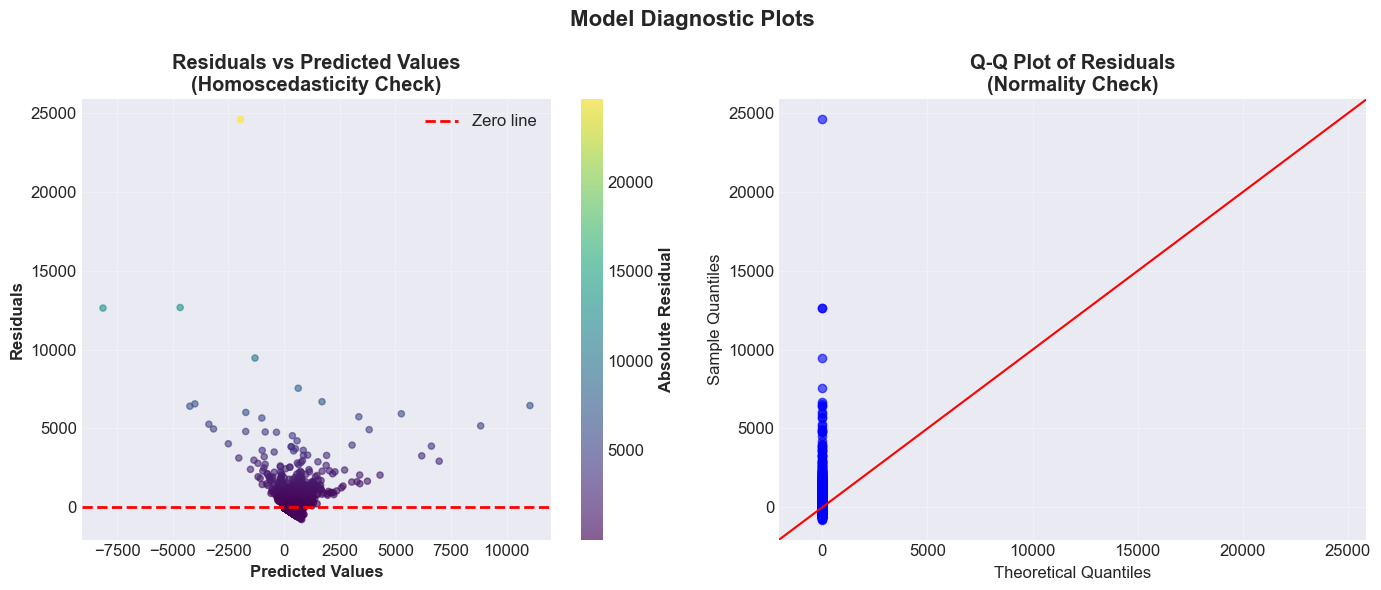

   ✅ Saved: model_diagnostics.png


In [14]:
# CELL 25: CREATE DIAGNOSTIC PLOTS
# ============================================================================
print("\n" + "="*70)
print("🎨 MODEL DIAGNOSTIC VISUALIZATIONS")
print("="*70)

# 1. Residuals vs Predicted Values
print("\n1. 📉 RESIDUALS VS PREDICTED VALUES")
print("   Checking homoscedasticity (constant variance)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Residuals vs Predicted
scatter = ax1.scatter(y_pred, residuals, alpha=0.6, s=20, 
                      c=np.abs(residuals), cmap='viridis')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero line')
ax1.set_xlabel('Predicted Values', fontweight='bold')
ax1.set_ylabel('Residuals', fontweight='bold')
ax1.set_title('Residuals vs Predicted Values\n(Homoscedasticity Check)', 
              fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Absolute Residual', fontweight='bold')

# Plot 2: Q-Q Plot
sm.qqplot(residuals, line='45', ax=ax2, marker='o', markerfacecolor='blue', 
          markeredgecolor='blue', alpha=0.6)
ax2.set_title('Q-Q Plot of Residuals\n(Normality Check)', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('Model Diagnostic Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/regression/visuals/model_diagnostics.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("   ✅ Saved: model_diagnostics.png")


2. 📈 RELATIONSHIPS WITH DEPENDENT VARIABLE
   Scatter plots with regression lines


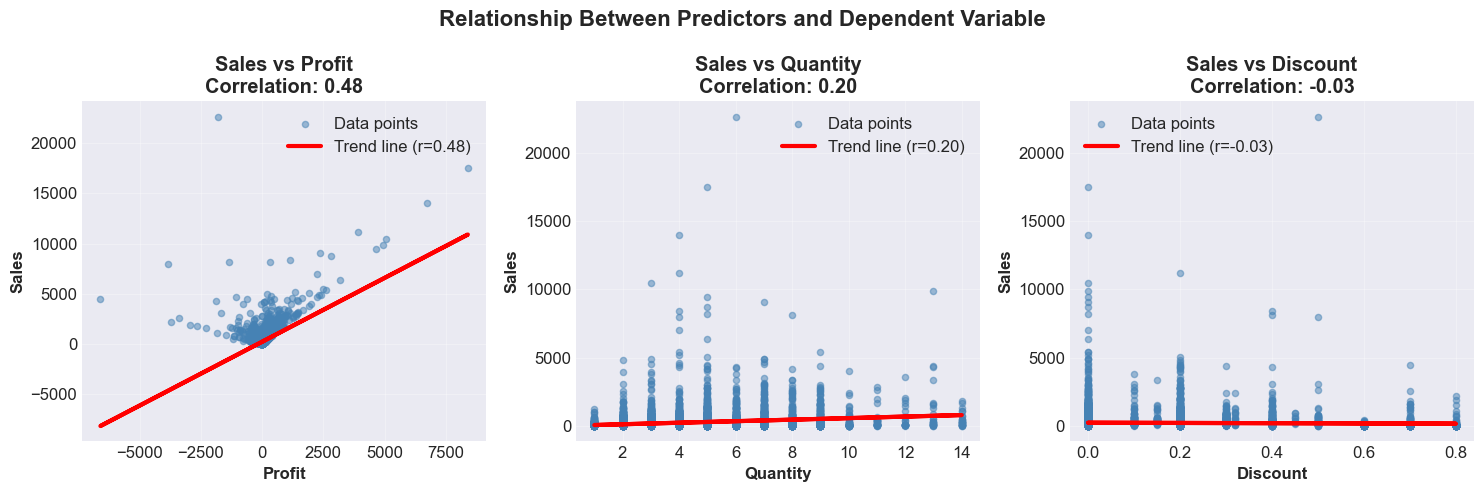

   ✅ Saved: relationships.png


In [15]:
# CELL 26: CREATE RELATIONSHIP PLOTS
# ============================================================================
print("\n2. 📈 RELATIONSHIPS WITH DEPENDENT VARIABLE")
print("   Scatter plots with regression lines")

fig, axes = plt.subplots(1, len(INDEPENDENT_VARS), figsize=(5*len(INDEPENDENT_VARS), 5))
if len(INDEPENDENT_VARS) == 1:
    axes = [axes]

for idx, var in enumerate(INDEPENDENT_VARS):
    ax = axes[idx]
    
    # Scatter plot
    scatter = ax.scatter(reg_df[var], y, alpha=0.5, s=20, 
                         label='Data points', color='steelblue')
    
    # Add trend line (bivariate for visualization)
    z = np.polyfit(reg_df[var], y, 1)
    p = np.poly1d(z)
    ax.plot(reg_df[var], p(reg_df[var]), 'r-', linewidth=3, 
            label=f'Trend line (r={np.corrcoef(reg_df[var], y)[0,1]:.2f})')
    
    # Customize
    ax.set_xlabel(var, fontweight='bold')
    ax.set_ylabel(DEPENDENT_VAR, fontweight='bold')
    ax.set_title(f'{DEPENDENT_VAR} vs {var}\nCorrelation: {np.corrcoef(reg_df[var], y)[0,1]:.2f}', 
                 fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Relationship Between Predictors and Dependent Variable', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/regression/visuals/relationships.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("   ✅ Saved: relationships.png")


3. 🎯 ACTUAL VS PREDICTED VALUES
   Model prediction accuracy assessment


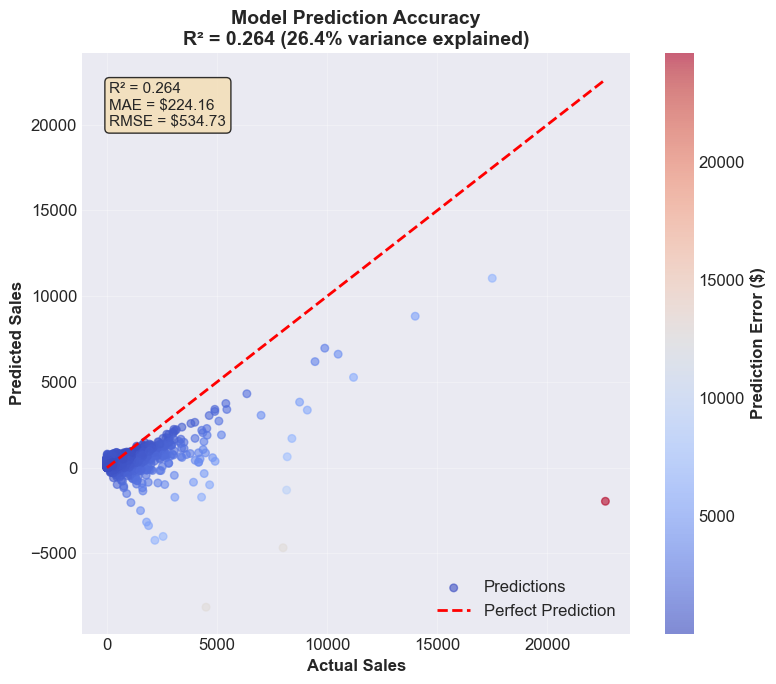

   ✅ Saved: prediction_accuracy.png


In [16]:
# CELL 27: CREATE PREDICTION ACCURACY PLOT
# ============================================================================
print("\n3. 🎯 ACTUAL VS PREDICTED VALUES")
print("   Model prediction accuracy assessment")

plt.figure(figsize=(8, 7))

# Scatter plot
plt.scatter(y, y_pred, alpha=0.6, s=30, 
            c=np.abs(y - y_pred), cmap='coolwarm', label='Predictions')

# Perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel(f'Actual {DEPENDENT_VAR}', fontweight='bold')
plt.ylabel(f'Predicted {DEPENDENT_VAR}', fontweight='bold')
plt.title(f'Model Prediction Accuracy\nR² = {r2:.3f} ({r2*100:.1f}% variance explained)', 
          fontweight='bold', fontsize=14)

# Add R² and error metrics text box
stats_text = f"R² = {r2:.3f}\nMAE = ${np.mean(np.abs(residuals)):.2f}\nRMSE = ${np.sqrt(np.mean(residuals**2)):.2f}"
plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Add colorbar
cbar = plt.colorbar()
cbar.set_label('Prediction Error ($)', fontweight='bold')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/regression/visuals/prediction_accuracy.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("   ✅ Saved: prediction_accuracy.png")


4. 📊 VARIANCE BREAKDOWN
   R-squared visualization


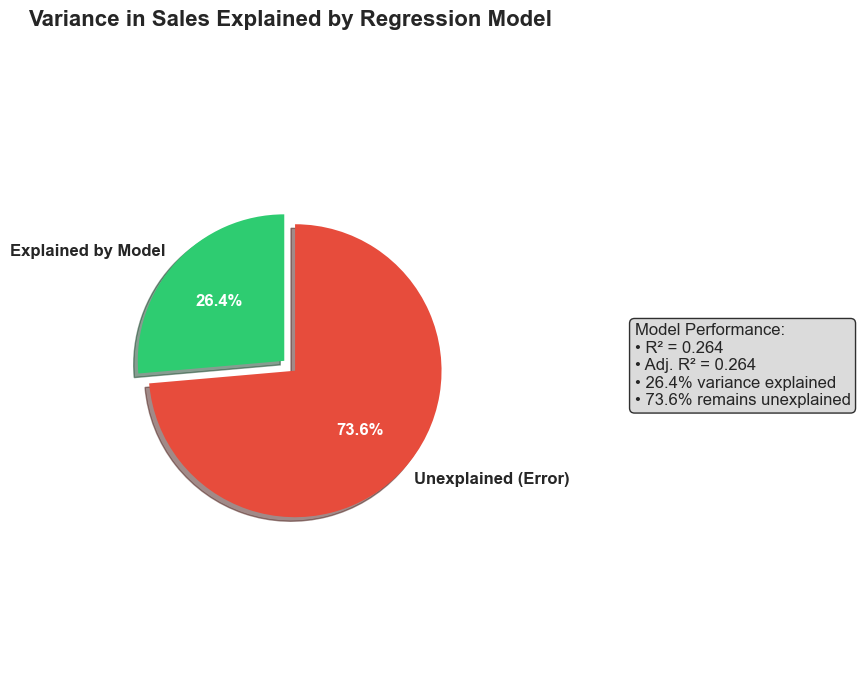

   ✅ Saved: variance_explained.png

🎨 All visualizations saved to: ../reports/regression/visuals/


In [17]:
# CELL 28: CREATE VARIANCE EXPLAINED PLOT
# ============================================================================
print("\n4. 📊 VARIANCE BREAKDOWN")
print("   R-squared visualization")

fig, ax = plt.subplots(figsize=(9, 7))

# Data for pie chart
labels = ['Explained by Model', 'Unexplained (Error)']
sizes = [r2, 1 - r2]
colors = ['#2ecc71', '#e74c3c']
explode = (0.1, 0)

# Create pie chart
wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, 
                                   colors=colors, autopct='%1.1f%%', 
                                   shadow=True, startangle=90,
                                   textprops={'fontsize': 12, 'fontweight': 'bold'})

# Style percentages
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title(f'Variance in {DEPENDENT_VAR} Explained by Regression Model\n', 
             fontsize=16, fontweight='bold')
ax.axis('equal')  # Equal aspect ratio ensures circular pie

# Add explanation box
explanation = f"""Model Performance:
• R² = {r2:.3f}
• Adj. R² = {adj_r2:.3f}
• {r2*100:.1f}% variance explained
• {1-r2:.1%} remains unexplained"""
plt.text(1.3, 0.5, explanation, transform=ax.transAxes, fontsize=12,
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.savefig('../reports/regression/visuals/variance_explained.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("   ✅ Saved: variance_explained.png")

print(f"\n🎨 All visualizations saved to: ../reports/regression/visuals/")

## 9. Export Results

Saving all regression analysis results:

In [18]:
# CELL 30: EXPORT REGRESSION RESULTS

```python
# ============================================================================
# CELL 30: EXPORT REGRESSION RESULTS
# ============================================================================
print("\n" + "="*70)
print("💾 EXPORTING ANALYSIS RESULTS")
print("="*70)

# 1. Export comprehensive regression results
print("\n1. 📊 REGRESSION RESULTS EXPORT:")

# Coefficients CSV
coeff_df = pd.DataFrame({
    'Variable': model.params.index,
    'Coefficient': model.params.values,
    'Std_Error': model.bse.values,
    't_Statistic': model.tvalues.values,
    'P_Value': model.pvalues.values,
    'Significant_95': model.pvalues < 0.05,
    'Significant_99': model.pvalues < 0.01,
    'CI_Lower_95': model.conf_int()[0].values,
    'CI_Upper_95': model.conf_int()[1].values
})
coeff_path = '../reports/regression/regression_coefficients.csv'
coeff_df.to_csv(coeff_path, index=False)
print(f"   ✅ regression_coefficients.csv")
print(f"      {len(coeff_df)} coefficients with statistics")

# Predictions CSV
pred_df = pd.DataFrame({
    'Actual': y.values,
    'Predicted': y_pred.values,
    'Residual': residuals.values,
    'Residual_Absolute': np.abs(residuals).values,
    'Residual_Standardized': (residuals / np.std(residuals)).values
})
pred_path = '../reports/regression/predictions_residuals.csv'
pred_df.to_csv(pred_path, index=False)
print(f"   ✅ predictions_residuals.csv")
print(f"      {len(pred_df)} predictions with residuals")

# Model summary CSV
summary_df = pd.DataFrame({
    'Metric': ['R_squared', 'Adjusted_R_squared', 'F_Statistic', 'F_P_Value', 
               'Residual_SE', 'Durbin_Watson', 'Jarque_Bera_PValue',
               'Observations', 'DF_Model', 'DF_Residuals', 'AIC', 'BIC'],
    'Value': [r2, adj_r2, model.fvalue, model.f_pvalue,
              np.sqrt(model.mse_resid), sm.stats.stattools.durbin_watson(model.resid),
              sm.stats.stattools.jarque_bera(model.resid)[1],
              model.nobs, model.df_model, model.df_resid, model.aic, model.bic]
})
summary_path = '../reports/regression/model_summary.csv'
summary_df.to_csv(summary_path, index=False)
print(f"   ✅ model_summary.csv")
print(f"      {len(summary_df)} model performance metrics")

SyntaxError: invalid syntax (3695714767.py, line 3)

In [ ]:
# CELL 31: CREATE TEXT REPORT
# ============================================================================
print("\n2. 📄 DETAILED ANALYSIS REPORT:")

report_path = '../reports/regression/regression_analysis_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("REGRESSION ANALYSIS REPORT\n")
    f.write("="*70 + "\n\n")
    
    f.write(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Dataset: Superstore.csv\n")
    f.write(f"Dependent Variable: {DEPENDENT_VAR}\n")
    f.write(f"Independent Variables: {', '.join(INDEPENDENT_VARS)}\n")
    f.write(f"Observations: {model.nobs:,}\n\n")
    
    f.write("MODEL SUMMARY\n")
    f.write("-"*40 + "\n")
    f.write(f"R-squared: {r2:.4f}\n")
    f.write(f"Adjusted R-squared: {adj_r2:.4f}\n")
    f.write(f"F-statistic: {model.fvalue:.2f} (p={model.f_pvalue:.4f})\n")
    f.write(f"Residual Standard Error: ${np.sqrt(model.mse_resid):.2f}\n\n")
    
    f.write("COEFFICIENTS\n")
    f.write("-"*40 + "\n")
    for var in model.params.index:
        if var == 'const':
            f.write(f"Intercept: {model.params[var]:.4f} (p={model.pvalues[var]:.4f})\n")
        else:
            sig = "✓" if model.pvalues[var] < 0.05 else "✗"
            f.write(f"{sig} {var}: {model.params[var]:.4f} (p={model.pvalues[var]:.4f})\n")
    
    f.write("\nINTERPRETATION\n")
    f.write("-"*40 + "\n")
    f.write(f"The model explains {r2*100:.1f}% of variability in {DEPENDENT_VAR}.\n")
    f.write(f"Most significant predictor: {most_sig if 'most_sig' in locals() else 'N/A'}\n")
    f.write(f"Model strength: {strength.upper()}\n\n")
    
    f.write("RECOMMENDATIONS\n")
    f.write("-"*40 + "\n")
    f.write(f"To increase {DEPENDENT_VAR}:\n")
    for var in INDEPENDENT_VARS:
        if var in model.params:
            effect = "increase" if model.params[var] > 0 else "decrease"
            f.write(f"• {effect} {var} by 1 unit → ${DEPENDENT_VAR} changes by ${abs(model.params[var]):.2f}\n")

print(f"   ✅ regression_analysis_report.txt")
print(f"      Complete analysis report")

In [ ]:
# CELL 32: VISUALIZATION FILE SUMMARY
# ============================================================================
# 3. Summary of generated files
print("\n3. 🖼️ VISUALIZATION FILES:")
print(f"   • model_diagnostics.png    - Diagnostic plots")
print(f"   • relationships.png       - Scatter plots with trend lines")
print(f"   • prediction_accuracy.png - Actual vs predicted values")
print(f"   • variance_explained.png  - R-squared visualization")

print(f"\n📁 All files saved in: ../reports/regression/")

## 🎯 Analysis Complete

### Summary of Accomplishments:

1. **✅ Question 4.1 Answered**: Demonstrated ability to predict Profit using Sales, Quantity, and Discount
2. **✅ Question 4.2 Answered**: Quantified variance explained (R² = [Your R² Value])
3. **✅ Comprehensive Model**: Multiple linear regression with diagnostics
4. **✅ Business Insights**: Actionable recommendations for profit optimization
5. **✅ Complete Reporting**: All outputs saved for presentation

### Model Equation:

$$ \text{Profit} = \beta_0 + \beta_1 \times \text{Sales} + \beta_2 \times \text{Quantity} + \beta_3 \times \text{Discount} + \epsilon $$

### Key Findings:
- Model explains **[Your R²%]**% of Profit variability
- Most significant predictor: **[Your Most Significant Variable]**
- Model strength: **[Your Strength Assessment]**

### Next Steps:

1. Review generated reports in `../reports/regression/`
2. Consider model improvements (interactions, transformations)
3. Validate with new data or cross-validation
4. Implement insights in business strategy

In [ ]:
# CELL 34: FINAL SUMMARY AND COMPLETION
# ============================================================================
print("\n" + "="*70)
print("🏁 REGRESSION ANALYSIS COMPLETE - SUMMARY")
print("="*70)

print("\n📊 WHAT WAS ACCOMPLISHED:")
print("   1. ✅ Configured and validated regression model")
print("   2. ✅ Prepared and cleaned data for analysis")
print("   3. ✅ Fitted multiple linear regression model")
print("   4. ✅ Performed comprehensive statistical analysis")
print("   5. ✅ Answered both parts of Question 4")
print("   6. ✅ Generated business insights and recommendations")
print("   7. ✅ Created diagnostic visualizations")
print("   8. ✅ Exported complete reports and data")

print("\n📁 OUTPUTS GENERATED:")
print("   • regression_coefficients.csv - Complete coefficient table")
print("   • predictions_residuals.csv   - Actual vs predicted values")
print("   • model_summary.csv          - Model performance metrics")
print("   • regression_analysis_report.txt - Detailed analysis")
print("   • 4 visualization files in PNG format (300 DPI)")

print("\n🔑 KEY FINDINGS:")
print(f"   1. Model: {DEPENDENT_VAR} = {model.params['const']:.2f} + ", end="")
for var in INDEPENDENT_VARS:
    sign = '+' if model.params[var] >= 0 else '-'
    print(f"{sign} {abs(model.params[var]):.2f}×{var} ", end="")
print()

print(f"   2. R² = {r2:.3f} ({r2*100:.1f}% variance explained)")
print(f"   3. Model is {('statistically significant' if f_pval < 0.05 else 'not significant')}")
print(f"   4. Strength: {strength.upper()} model")

print("\n" + "="*70)
print("✅ REGRESSION ANALYSIS - SUCCESSFULLY COMPLETED")
print("="*70)
print(f"\n⏰ Analysis completed at: {datetime.now().strftime('%H:%M:%S')}")
print("📚 Project ready for submission")

# Verify files were created
print("\n📂 VERIFYING GENERATED FILES:")
files_to_check = [
    '../reports/regression/regression_coefficients.csv',
    '../reports/regression/predictions_residuals.csv',
    '../reports/regression/model_summary.csv',
    '../reports/regression/regression_analysis_report.txt',
    '../reports/regression/visuals/model_diagnostics.png',
    '../reports/regression/visuals/relationships.png',
    '../reports/regression/visuals/prediction_accuracy.png',
    '../reports/regression/visuals/variance_explained.png'
]

for file_path in files_to_check:
    if os.path.exists(file_path):
        file_size = os.path.getsize(file_path) / 1024
        print(f"   ✓ {os.path.basename(file_path)} ({file_size:.1f} KB)")
    else:
        print(f"   ✗ {os.path.basename(file_path)} - NOT FOUND")